In [43]:
import pandas as pd

# load ground truth and data into pandas
ground_truth_file = "ground_truthing.xlsx"
ground_truth = pd.read_excel(ground_truth_file, sheet_name=0)
data = pd.read_excel(ground_truth_file, sheet_name=1)

In [44]:
# Streak rule analysis
import numpy as np

# First, let's convert the data to a long format suitable for streak analysis
def convert_to_long_format(df, dataset_name):
    """Convert wide format data to long format for streak analysis"""
    mites_data = []
    
    for idx, row in df.iterrows():
        mite_id = row['mite ID']
        recording_num = 1
        for col in df.columns[1:]:  # Skip 'mite ID' column
            time_point = int(col.split()[0])  # Extract minutes
            status = row[col]
            status_num = 1 if status == 'dead' else 0  # 1 for dead, 0 for alive
            
            mites_data.append({
                'mite ID': mite_id,
                'recording': recording_num,
                'time_minutes': time_point,
                'status': status,
                'status_num': status_num,
                'dataset': dataset_name
            })
            recording_num += 1
    
    return pd.DataFrame(mites_data)

# Convert both datasets to long format
ground_truth_long = convert_to_long_format(ground_truth, 'ground_truth')
data_long = convert_to_long_format(data, 'data')

# Define streak length for analysis
streak = 12  # You can adjust this value

def get_streak_start(series):
    """Find the start of a consecutive dead streak"""
    # Reset index to work with integer positions
    series_reset = series.reset_index(drop=True)
    rolling_sum = series_reset.rolling(window=streak).sum()
    mask = rolling_sum == streak
    if mask.any():
        idx = mask.idxmax()  # first index where streak occurs
        return idx - streak + 2  # Convert to recording number (1-based)
    else:
        return np.nan

def analyze_streaks(df_long, dataset_name):
    """Analyze streaks for a dataset"""
    mites_data = df_long.copy()
    
    # Group by mite_ID and compute streak_start per mite
    streak_starts = mites_data.groupby("mite ID")["status_num"].apply(get_streak_start)
    
    # Map the streak_start back to the original DataFrame
    mites_data["streak_start"] = mites_data["mite ID"].map(streak_starts)
    
    # Calculate streak_end for each mite
    mites_data["streak_end"] = mites_data["streak_start"] + streak - 1
    
    print(f"{dataset_name} Streak Analysis:")
    print("="*50)
    streak_summary = mites_data.groupby('mite ID')[['streak_start', 'streak_end']].first()
    streak_summary = streak_summary.dropna()
    
    if len(streak_summary) > 0:
        print(f"Mites with {streak}-consecutive dead streak:")
        for mite_id, row in streak_summary.iterrows():
            start_time = (row['streak_start'] - 1) * 5 + 5  # Convert to minutes
            end_time = (row['streak_end'] - 1) * 5 + 5
            print(f"  {mite_id}: recordings {row['streak_start']:.0f}-{row['streak_end']:.0f} ({start_time:.0f}-{end_time:.0f} minutes)")
    else:
        print(f"No mites found with {streak}-consecutive dead streak")
    
    total_mites = len(mites_data['mite ID'].unique())
    print(f"\nTotal mites with {streak}-streak: {len(streak_summary)}/{total_mites}")
    
    return mites_data, streak_summary

# Analyze both datasets
print("STREAK ANALYSIS RESULTS")
print("="*60)

# Ground truth analysis
gt_mites_data, gt_streak_summary = analyze_streaks(ground_truth_long, "Ground Truth")

print()

# Data analysis  
data_mites_data, data_streak_summary = analyze_streaks(data_long, "Data (Predicted)")

# Compare the results
print(f"\nCOMPARISON:")
print("="*30)
print(f"Ground Truth streaks: {len(gt_streak_summary)} mites")
print(f"Predicted Data streaks: {len(data_streak_summary)} mites")

if len(gt_streak_summary) > 0 and len(data_streak_summary) > 0:
    # Find common mites with streaks
    gt_mites = set(gt_streak_summary.index)
    data_mites = set(data_streak_summary.index)
    common_mites = gt_mites.intersection(data_mites)
    
    print(f"Mites with streaks in both datasets: {len(common_mites)}")
    print(f"Mites with streaks only in ground truth: {len(gt_mites - data_mites)}")
    print(f"Mites with streaks only in predicted data: {len(data_mites - gt_mites)}")
    
    if common_mites:
        print(f"\nCommon mites: {sorted(list(common_mites))}")

STREAK ANALYSIS RESULTS
Ground Truth Streak Analysis:
Mites with 12-consecutive dead streak:
  mite_0001: recordings 49-60 (245-300 minutes)
  mite_0003: recordings 73-84 (365-420 minutes)
  mite_0004: recordings 61-72 (305-360 minutes)
  mite_0005: recordings 31-42 (155-210 minutes)
  mite_0007: recordings 73-84 (365-420 minutes)
  mite_0008: recordings 73-84 (365-420 minutes)
  mite_0009: recordings 73-84 (365-420 minutes)
  mite_0010: recordings 73-84 (365-420 minutes)
  mite_0012: recordings 73-84 (365-420 minutes)
  mite_0013: recordings 73-84 (365-420 minutes)
  mite_0015: recordings 61-72 (305-360 minutes)
  mite_0017: recordings 73-84 (365-420 minutes)
  mite_0020: recordings 73-84 (365-420 minutes)
  mite_0022: recordings 61-72 (305-360 minutes)
  mite_0026: recordings 73-84 (365-420 minutes)
  mite_0028: recordings 73-84 (365-420 minutes)
  mite_0029: recordings 49-60 (245-300 minutes)

Total mites with 12-streak: 17/18

Data (Predicted) Streak Analysis:
Mites with 12-consecu

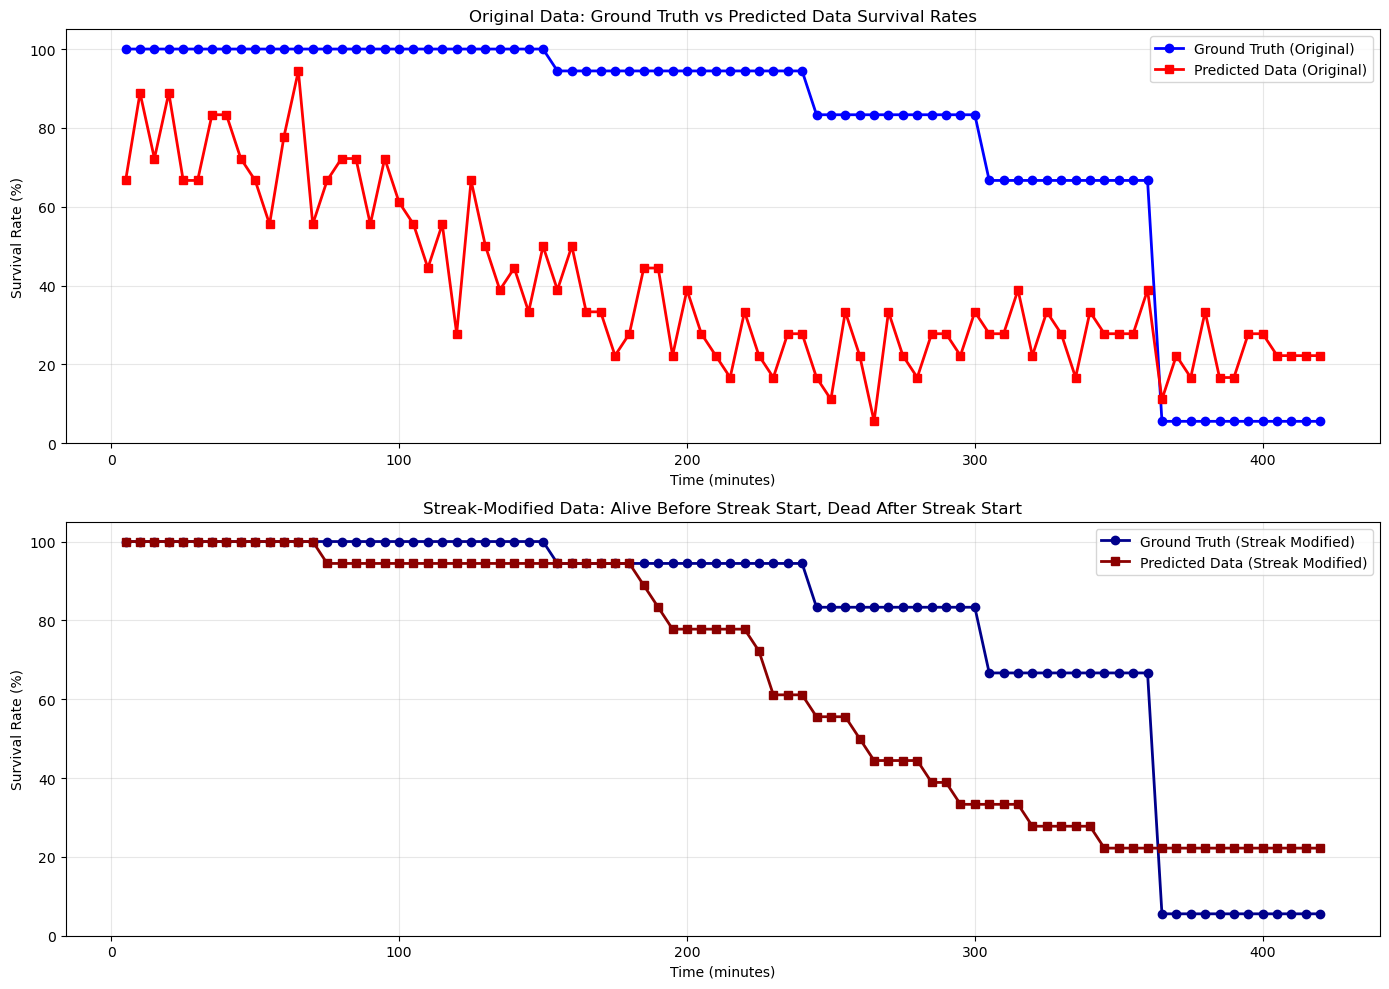

MODIFICATION STATISTICS:
Ground Truth:
  - Total mites: 18
  - Mites with streaks (modified): 17
  - Mites without streaks (set to alive all time): 1

Predicted Data:
  - Total mites: 18
  - Mites with streaks (modified): 14
  - Mites without streaks (set to alive all time): 4

Mean Absolute Error (Survival Rates):
Original data: 43.06%
Streak-modified data: 17.39%
Improvement: 25.66%

Final Survival Rates (at last time point):
Ground Truth - Original: 5.6%, Modified: 5.6%
Predicted Data - Original: 22.2%, Modified: 22.2%


In [45]:
import matplotlib.pyplot as plt
import numpy as np

def modify_data_with_streaks(df_long, streak_summary):
    """Modify data so mites are alive before streak start and dead after streak start.
    Mites without streaks are set to alive all the time."""
    df_modified = df_long.copy()
    
    # Get all unique mite IDs
    all_mites = df_modified['mite ID'].unique()
    mites_with_streaks = set(streak_summary.index) if len(streak_summary) > 0 else set()
    
    # For mites WITHOUT streaks: set them to alive all the time
    for mite_id in all_mites:
        if mite_id not in mites_with_streaks:
            mite_mask = df_modified['mite ID'] == mite_id
            df_modified.loc[mite_mask, 'status_num'] = 0  # alive
            df_modified.loc[mite_mask, 'status'] = 'alive'
    
    # For mites WITH streaks: alive before streak start, dead after streak start
    for mite_id, streak_info in streak_summary.iterrows():
        streak_start = streak_info['streak_start']
        
        # Get all recordings for this mite
        mite_mask = df_modified['mite ID'] == mite_id
        mite_data = df_modified[mite_mask].copy()
        
        # Modify status: alive (0) before streak_start, dead (1) from streak_start onwards
        mite_data.loc[mite_data['recording'] < streak_start, 'status_num'] = 0
        mite_data.loc[mite_data['recording'] >= streak_start, 'status_num'] = 1
        mite_data.loc[mite_data['recording'] < streak_start, 'status'] = 'alive'
        mite_data.loc[mite_data['recording'] >= streak_start, 'status'] = 'dead'
        
        # Update the main dataframe
        df_modified.loc[mite_mask] = mite_data
    
    return df_modified

# Apply streak-based modification to both datasets
gt_modified = modify_data_with_streaks(ground_truth_long, gt_streak_summary)
data_modified = modify_data_with_streaks(data_long, data_streak_summary)

# Calculate survival rates (percentage alive) at each time point for modified data
def calculate_survival_rates(df_long):
    """Calculate survival rates at each time point"""
    survival_rates = []
    time_points = sorted(df_long['time_minutes'].unique())
    
    for time_point in time_points:
        time_data = df_long[df_long['time_minutes'] == time_point]
        total_mites = len(time_data)
        alive_mites = len(time_data[time_data['status_num'] == 0])
        survival_rate = (alive_mites / total_mites) * 100 if total_mites > 0 else 0
        survival_rates.append(survival_rate)
    
    return time_points, survival_rates

# Calculate survival rates for both original and modified data
gt_time_original, gt_survival_original = calculate_survival_rates(ground_truth_long)
data_time_original, data_survival_original = calculate_survival_rates(data_long)

gt_time_modified, gt_survival_modified = calculate_survival_rates(gt_modified)
data_time_modified, data_survival_modified = calculate_survival_rates(data_modified)

# Create the line graph
plt.figure(figsize=(14, 10))

# Original data subplot
plt.subplot(2, 1, 1)
plt.plot(gt_time_original, gt_survival_original, 'o-', label='Ground Truth (Original)', 
         color='blue', linewidth=2, markersize=6)
plt.plot(data_time_original, data_survival_original, 's-', label='Predicted Data (Original)', 
         color='red', linewidth=2, markersize=6)
plt.xlabel('Time (minutes)')
plt.ylabel('Survival Rate (%)')
plt.title('Original Data: Ground Truth vs Predicted Data Survival Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

# Modified data subplot (with streak-based modification)
plt.subplot(2, 1, 2)
plt.plot(gt_time_modified, gt_survival_modified, 'o-', label='Ground Truth (Streak Modified)', 
         color='darkblue', linewidth=2, markersize=6)
plt.plot(data_time_modified, data_survival_modified, 's-', label='Predicted Data (Streak Modified)', 
         color='darkred', linewidth=2, markersize=6)
plt.xlabel('Time (minutes)')
plt.ylabel('Survival Rate (%)')
plt.title('Streak-Modified Data: Alive Before Streak Start, Dead After Streak Start')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)

plt.tight_layout()
plt.show()

# Print some statistics about the modification
print("MODIFICATION STATISTICS:")
print("="*50)

# Calculate mites without streaks
gt_total_mites = len(ground_truth_long['mite ID'].unique())
data_total_mites = len(data_long['mite ID'].unique())
gt_mites_without_streaks = gt_total_mites - len(gt_streak_summary)
data_mites_without_streaks = data_total_mites - len(data_streak_summary)

print(f"Ground Truth:")
print(f"  - Total mites: {gt_total_mites}")
print(f"  - Mites with streaks (modified): {len(gt_streak_summary)}")
print(f"  - Mites without streaks (set to alive all time): {gt_mites_without_streaks}")

print(f"\nPredicted Data:")
print(f"  - Total mites: {data_total_mites}")
print(f"  - Mites with streaks (modified): {len(data_streak_summary)}")
print(f"  - Mites without streaks (set to alive all time): {data_mites_without_streaks}")

# Calculate mean absolute error between ground truth and predicted data
def calculate_mae(gt_rates, pred_rates):
    """Calculate Mean Absolute Error between two survival rate lists"""
    return np.mean(np.abs(np.array(gt_rates) - np.array(pred_rates)))

mae_original = calculate_mae(gt_survival_original, data_survival_original)
mae_modified = calculate_mae(gt_survival_modified, data_survival_modified)

print(f"\nMean Absolute Error (Survival Rates):")
print(f"Original data: {mae_original:.2f}%")
print(f"Streak-modified data: {mae_modified:.2f}%")
print(f"Improvement: {mae_original - mae_modified:.2f}%")

# Show final survival rates
print(f"\nFinal Survival Rates (at last time point):")
print(f"Ground Truth - Original: {gt_survival_original[-1]:.1f}%, Modified: {gt_survival_modified[-1]:.1f}%")
print(f"Predicted Data - Original: {data_survival_original[-1]:.1f}%, Modified: {data_survival_modified[-1]:.1f}%")

Calculating survival rates for different streak lengths...
Processing streak length: 2
Processing streak length: 5
Processing streak length: 8
Processing streak length: 10
Processing streak length: 12
Processing streak length: 15
Creating ground truth comparison...
Creating predicted data comparison...


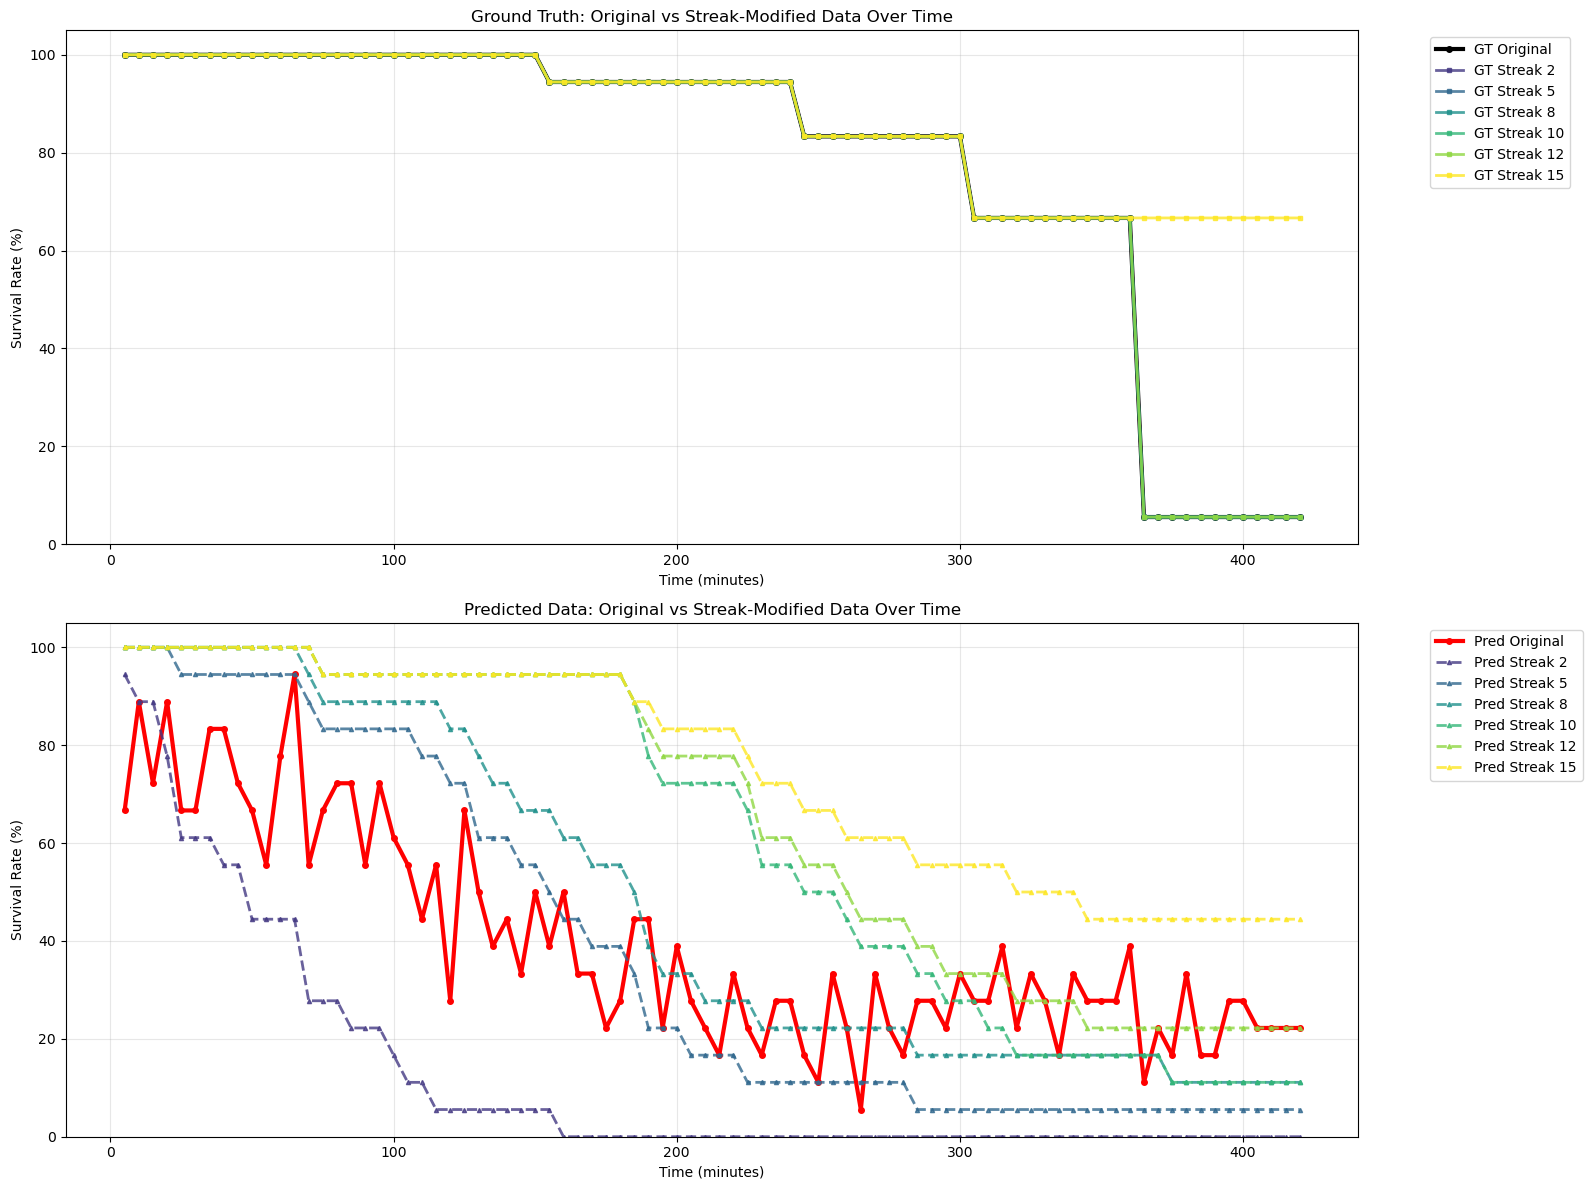

Creating combined comparison...


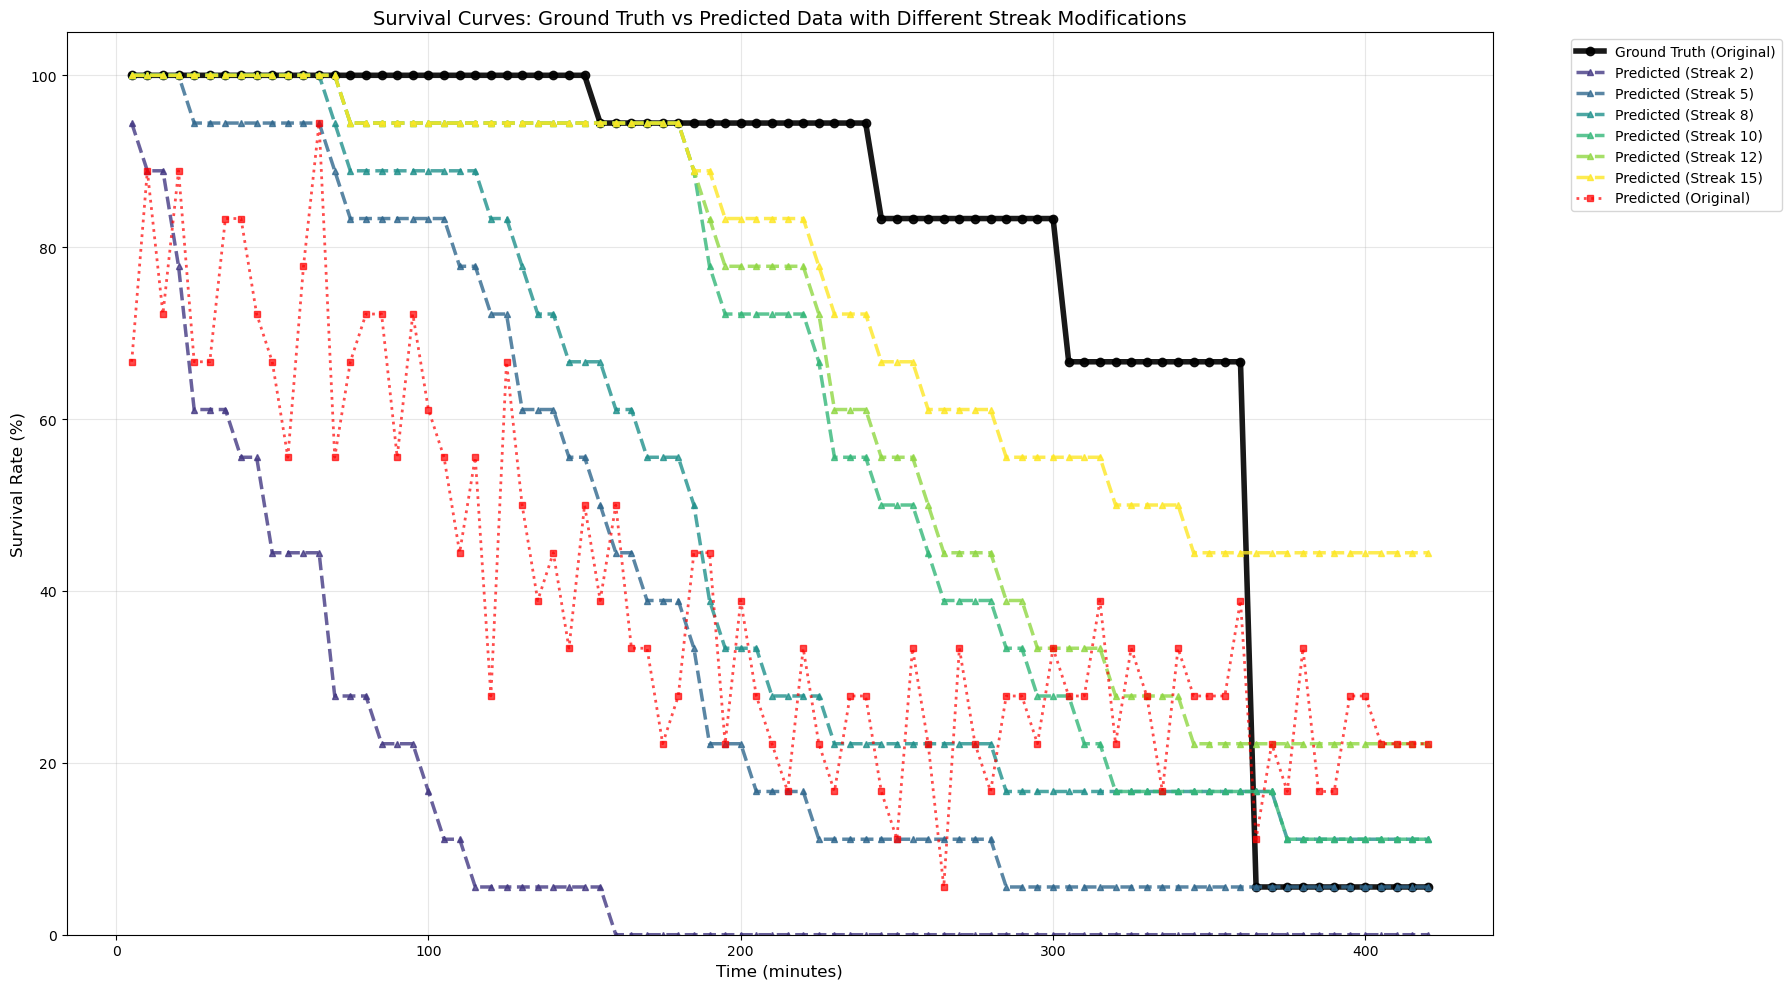

SURVIVAL CURVE ANALYSIS:
Final Survival Rates and MAE:
Original       : GT=  5.6%, Pred= 22.2%, Diff= 16.7%, MAE=43.06%
Streak 2       : GT=  5.6%, Pred=  0.0%, Diff=  5.6%, MAE=65.54%
Streak 5       : GT=  5.6%, Pred=  5.6%, Diff=  0.0%, MAE=39.75%
Streak 8       : GT=  5.6%, Pred= 11.1%, Diff=  5.6%, MAE=32.08%
Streak 10      : GT=  5.6%, Pred= 11.1%, Diff=  5.6%, MAE=18.72%
Streak 12      : GT=  5.6%, Pred= 22.2%, Diff= 16.7%, MAE=17.39%
Streak 15      : GT= 66.7%, Pred= 44.4%, Diff= 22.2%, MAE=11.84%

Best final survival rate match: Streak 5
Ground Truth final: 5.6%
Predicted final: 5.6%
Difference: 0.0%
MAE: 39.75%


In [47]:
# Create line graph showing ground truth and various streak lengths vs time
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# First, calculate survival rates for each streak length modification
streak_lengths_to_plot = [2, 5, 8, 10, 12, 15]  # Select subset for clarity
survival_data_by_streak = {}

print("Calculating survival rates for different streak lengths...")

# Add original data (no modification)
gt_time_orig, gt_survival_orig = calculate_survival_rates_local(ground_truth_long)
data_time_orig, data_survival_orig = calculate_survival_rates_local(data_long)
survival_data_by_streak['Original'] = {
    'gt_time': gt_time_orig,
    'gt_survival': gt_survival_orig,
    'data_time': data_time_orig,
    'data_survival': data_survival_orig
}

# Calculate for selected streak lengths
for streak_len in streak_lengths_to_plot:
    print(f"Processing streak length: {streak_len}")
    
    # Analyze streaks
    gt_data_temp, gt_streaks_temp = analyze_streak_length(ground_truth_long, streak_len)
    data_data_temp, data_streaks_temp = analyze_streak_length(data_long, streak_len)
    
    # Apply modifications
    gt_mod_temp = modify_data_with_streaks_local(ground_truth_long, gt_streaks_temp)
    data_mod_temp = modify_data_with_streaks_local(data_long, data_streaks_temp)
    
    # Calculate survival rates
    gt_time_temp, gt_survival_temp = calculate_survival_rates_local(gt_mod_temp)
    data_time_temp, data_survival_temp = calculate_survival_rates_local(data_mod_temp)
    
    survival_data_by_streak[f'Streak {streak_len}'] = {
        'gt_time': gt_time_temp,
        'gt_survival': gt_survival_temp,
        'data_time': data_time_temp,
        'data_survival': data_survival_temp
    }

# Create the visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Generate colors for different streak lengths
colors = cm.viridis(np.linspace(0, 1, len(survival_data_by_streak)))

# Plot 1: Ground Truth with different streak modifications
print("Creating ground truth comparison...")
for i, (label, data) in enumerate(survival_data_by_streak.items()):
    if label == 'Original':
        ax1.plot(data['gt_time'], data['gt_survival'], 
                linewidth=3, label=f'GT {label}', 
                color='black', linestyle='-', marker='o', markersize=4)
    else:
        ax1.plot(data['gt_time'], data['gt_survival'], 
                linewidth=2, label=f'GT {label}', 
                color=colors[i], linestyle='-', marker='s', markersize=3, alpha=0.8)

ax1.set_xlabel('Time (minutes)')
ax1.set_ylabel('Survival Rate (%)')
ax1.set_title('Ground Truth: Original vs Streak-Modified Data Over Time')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

# Plot 2: Predicted Data with different streak modifications
print("Creating predicted data comparison...")
for i, (label, data) in enumerate(survival_data_by_streak.items()):
    if label == 'Original':
        ax2.plot(data['data_time'], data['data_survival'], 
                linewidth=3, label=f'Pred {label}', 
                color='red', linestyle='-', marker='o', markersize=4)
    else:
        ax2.plot(data['data_time'], data['data_survival'], 
                linewidth=2, label=f'Pred {label}', 
                color=colors[i], linestyle='--', marker='^', markersize=3, alpha=0.8)

ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Survival Rate (%)')
ax2.set_title('Predicted Data: Original vs Streak-Modified Data Over Time')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Create a combined comparison plot
fig, ax = plt.subplots(1, 1, figsize=(18, 10))

print("Creating combined comparison...")

# Plot ground truth (original) as reference
ax.plot(survival_data_by_streak['Original']['gt_time'], 
        survival_data_by_streak['Original']['gt_survival'], 
        linewidth=4, label='Ground Truth (Original)', 
        color='black', linestyle='-', marker='o', markersize=6, alpha=0.9)

# Plot predicted data with different streak modifications
for i, streak_len in enumerate(streak_lengths_to_plot):
    label = f'Streak {streak_len}'
    data = survival_data_by_streak[label]
    
    ax.plot(data['data_time'], data['data_survival'], 
            linewidth=2.5, label=f'Predicted (Streak {streak_len})', 
            color=colors[i+1], linestyle='--', marker='^', markersize=4, alpha=0.8)

# Also plot original predicted data for comparison
ax.plot(survival_data_by_streak['Original']['data_time'], 
        survival_data_by_streak['Original']['data_survival'], 
        linewidth=2, label='Predicted (Original)', 
        color='red', linestyle=':', marker='s', markersize=4, alpha=0.7)

ax.set_xlabel('Time (minutes)', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_title('Survival Curves: Ground Truth vs Predicted Data with Different Streak Modifications', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Print some insights about the patterns
print("SURVIVAL CURVE ANALYSIS:")
print("="*50)

# Calculate final survival rates for each modification
final_survival_rates = {}
for label, data in survival_data_by_streak.items():
    gt_final = data['gt_survival'][-1] if data['gt_survival'] else 0
    pred_final = data['data_survival'][-1] if data['data_survival'] else 0
    mae = calculate_mae_local(data['gt_survival'], data['data_survival'])
    
    final_survival_rates[label] = {
        'gt_final': gt_final,
        'pred_final': pred_final,
        'mae': mae,
        'difference': abs(gt_final - pred_final)
    }

print("Final Survival Rates and MAE:")
for label, rates in final_survival_rates.items():
    print(f"{label:15}: GT={rates['gt_final']:5.1f}%, Pred={rates['pred_final']:5.1f}%, "
          f"Diff={rates['difference']:5.1f}%, MAE={rates['mae']:5.2f}%")

# Find the modification that gives the closest final survival rate to ground truth
best_final_match = min(final_survival_rates.items(), 
                      key=lambda x: x[1]['difference'] if x[0] != 'Original' else float('inf'))

print(f"\nBest final survival rate match: {best_final_match[0]}")
print(f"Ground Truth final: {best_final_match[1]['gt_final']:.1f}%")
print(f"Predicted final: {best_final_match[1]['pred_final']:.1f}%")
print(f"Difference: {best_final_match[1]['difference']:.1f}%")
print(f"MAE: {best_final_match[1]['mae']:.2f}%")

In [ ]:
# Create overlay plot: Original Ground Truth vs Predicted Data with Different Streak Modifications
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create a single overlay plot
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

print("Creating overlay plot: Original Ground Truth vs Predicted Data with Streak Modifications...")

# Plot original ground truth as the reference (thick black line)
original_gt_time = survival_data_by_streak['Original']['gt_time']
original_gt_survival = survival_data_by_streak['Original']['gt_survival']

ax.plot(original_gt_time, original_gt_survival, 
        linewidth=5, label='Ground Truth (Original)', 
        color='black', linestyle='-', marker='o', markersize=8, alpha=1.0, zorder=10)

# Generate colors for different streak lengths
streak_lengths_to_plot = [2, 5, 8, 10, 12, 15]
colors = cm.tab10(np.linspace(0, 1, len(streak_lengths_to_plot) + 1))

# Plot original predicted data first (as baseline)
original_pred_time = survival_data_by_streak['Original']['data_time']
original_pred_survival = survival_data_by_streak['Original']['data_survival']

ax.plot(original_pred_time, original_pred_survival, 
        linewidth=2, label='Predicted (Original - No Modification)', 
        color='red', linestyle=':', marker='s', markersize=3, alpha=0.8, zorder=5)

# Plot predicted data with different streak modifications
for i, streak_len in enumerate(streak_lengths_to_plot):
    label = f'Streak {streak_len}'
    data = survival_data_by_streak[label]
    
    ax.plot(data['data_time'], data['data_survival'], 
            linewidth=2.5, label=f'Predicted (Streak {streak_len})', 
            color=colors[i], linestyle='--', marker='^', markersize=4, alpha=0.85, zorder=7)

# Formatting
ax.set_xlabel('Time (minutes)', fontsize=14)
ax.set_ylabel('Survival Rate (%)', fontsize=14)
ax.set_title('Original Ground Truth vs Predicted Data with Different Streak Modifications', fontsize=16, pad=20)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
ax.set_xlim(0, max(original_gt_time) + 10)

# Add text box with key statistics
textstr = f'''Key Statistics:
Original GT Final: {original_gt_survival[-1]:.1f}%
Original Pred Final: {original_pred_survival[-1]:.1f}%

Best MAE Improvement:
{best_final_match[0]}: {best_final_match[1]['mae']:.2f}%'''

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Print comparison table
print("\nCOMPARISON TABLE: Original Ground Truth vs Predicted Data Modifications")
print("="*85)
print(f"{'Modification':<20} {'Pred Final (%)':<15} {'GT Final (%)':<15} {'Difference (%)':<15} {'MAE (%)':<10}")
print("-"*85)

gt_final_ref = original_gt_survival[-1]
for label, rates in final_survival_rates.items():
    if 'Streak' in label or label == 'Original':
        print(f"{label:<20} {rates['pred_final']:<15.1f} {gt_final_ref:<15.1f} "
              f"{abs(rates['pred_final'] - gt_final_ref):<15.1f} {rates['mae']:<10.2f}")

print("-"*85)
print(f"Reference: Original Ground Truth Final Survival Rate = {gt_final_ref:.1f}%")